<a href="https://colab.research.google.com/github/surankan-de/surankan-de/blob/main/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio
!pip install pandas scikit-learn tqdm datasets kaggle


In [2]:
!wget --content-disposition http://nlp.stanford.edu/data/glove.840B.300d.zip
!unzip -q glove.840B.300d.zip


--2026-03-28 17:27:49--  http://nlp.stanford.edu/data/glove.840B.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.840B.300d.zip [following]
--2026-03-28 17:27:50--  https://nlp.stanford.edu/data/glove.840B.300d.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.840B.300d.zip [following]
--2026-03-28 17:27:51--  https://downloads.cs.stanford.edu/nlp/data/glove.840B.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2176768927 (2.0G) [application/

In [3]:
import math
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# CONFIG
MAX_LEN        = 50
WORD_DIM       = 300
CAT_DIM        = 100
NUM_HEADS      = 4
FFN_DIM1       = 400
FFN_DIM2       = 200
N_EXPERTS      = 3
DROPOUT        = 0.1
BATCH_SIZE     = 512
LR             = 5e-4
WEIGHT_DECAY   = 1e-5
MAX_EPOCHS     = 5
PATIENCE       = 5
SENT_RATIO     = 2.0
GLOVE_PATH     = "glove.840B.300d.txt"
DAVIDSON_PATH  = "labeled_data.csv"
SENTIMENT_PATH = "sentiment_train.csv"
DEROG_PATH     = "word_all.txt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
def clean(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    return text.strip()

def load_davidson(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["tweet"] = df["tweet"].apply(clean)
    df["hate_label"] = (df["class"] == 0).astype(int)
    return df[["tweet", "hate_label"]]

from datasets import load_dataset
import pandas as pd

def load_sentiment_data():
    """
    Uses HuggingFace tweet_eval sentiment dataset.
    Original labels:
        0 = negative
        1 = neutral
        2 = positive

    We convert to binary:
        0 = negative
        1 = neutral + positive
    """

    print("Downloading tweet_eval sentiment dataset...")
    ds = load_dataset("tweet_eval", "sentiment", split="train")

    rows = []
    for x in ds:
        label = 0 if x["label"] == 0 else 1  # binary conversion
        rows.append({
            "tweet": clean(x["text"]),
            "sent_label": label
        })

    df = pd.DataFrame(rows)
    print("Sentiment dataset loaded:", len(df))
    return df



In [5]:
def build_vocab(*text_lists):
    all_words = " ".join(w for lst in text_lists for w in lst).split()
    vocab = Counter(all_words)
    word2idx = {w: i + 2 for i, (w, _) in enumerate(vocab.items())}
    word2idx["<PAD>"] = 0
    word2idx["<UNK>"] = 1
    return word2idx

def load_glove(path, word2idx):
    embedding_matrix = np.zeros((len(word2idx), WORD_DIM), dtype=np.float32)
    found = 0
    with open(path, encoding="utf8", errors="ignore") as f:
        for line in tqdm(f, desc="Loading GloVe"):
            values = line.rstrip().split(" ")
            if len(values) != WORD_DIM + 1:
                continue
            word = values[0]
            if word in word2idx:
                embedding_matrix[word2idx[word]] = np.asarray(values[1:], dtype=np.float32)
                found += 1
    print(f"GloVe coverage: {found}/{len(word2idx)}")
    return embedding_matrix

def load_derog(path):
    with open(path, encoding="utf8") as f:
        return set(w.strip().lower() for w in f.readlines() if w.strip())


In [6]:
word2idx_global = {}
derog_global = set()

def encode(text):
    tokens = text.split()[:MAX_LEN]
    ids, cat = [], []
    for t in tokens:
        ids.append(word2idx_global.get(t, 1))
        cat.append(1 if t in derog_global else 0)
    pad_len = MAX_LEN - len(ids)
    ids += [0] * pad_len
    cat += [0] * pad_len
    return ids, cat

class HateDataset(Dataset):
    def __init__(self, df):
        self.texts  = df["tweet"].values
        self.labels = df["hate_label"].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, cat = encode(self.texts[idx])
        return (
            torch.tensor(ids),
            torch.tensor(cat),
            torch.tensor(self.labels[idx])
        )

class SentimentDataset(Dataset):
    def __init__(self, df):
        self.texts  = df["tweet"].values
        self.labels = df["sent_label"].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, cat = encode(self.texts[idx])
        return (
            torch.tensor(ids),
            torch.tensor(cat),
            torch.tensor(self.labels[idx])
        )


In [7]:
class FeatureExtractionUnit(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.mha = nn.MultiheadAttention(
            embed_dim=input_dim,
            num_heads=NUM_HEADS,
            dropout=DROPOUT,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(input_dim)
        self.dropout1 = nn.Dropout(DROPOUT)

        # FFN1 now works on token-level features
        self.ffn1 = nn.Sequential(
            nn.Linear(input_dim, FFN_DIM1),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )
        self.norm2 = nn.LayerNorm(FFN_DIM1)

        # FFN2 works after pooling (so input is doubled)
        self.ffn2 = nn.Sequential(
            nn.Linear(FFN_DIM1 * 2, FFN_DIM2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )
        self.norm3 = nn.LayerNorm(FFN_DIM2)

    def forward(self, x):
        # Self-attention
        attn_out, _ = self.mha(x, x, x)
        x = self.norm1(x + self.dropout1(attn_out))

        # FFN1 (token-wise)
        x = self.ffn1(x)
        x = self.norm2(x)

        # Pool AFTER FFN1
        p_max, _ = x.max(dim=1)
        p_avg = x.mean(dim=1)
        pooled = torch.cat([p_max, p_avg], dim=1)

        # FFN2 (on pooled features)
        out = self.ffn2(pooled)
        out = self.norm3(out)

        return out


In [8]:
class GatingNetwork(nn.Module):
    def __init__(self, input_dim, n_experts):
        super().__init__()
        self.unit = FeatureExtractionUnit(input_dim)
        self.fc = nn.Linear(FFN_DIM2, n_experts)

    def forward(self, x):
        h = self.unit(x)
        return torch.softmax(self.fc(h), dim=1)

class SKS(nn.Module):
    def __init__(self, vocab_size, embedding_matrix):
        super().__init__()

        self.word_embed = nn.Embedding(vocab_size, WORD_DIM, padding_idx=0)
        self.word_embed.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.cat_embed = nn.Embedding(2, CAT_DIM)
        input_dim = WORD_DIM + CAT_DIM

        self.experts = nn.ModuleList(
            [FeatureExtractionUnit(input_dim) for _ in range(N_EXPERTS)]
        )

        self.hate_gate = GatingNetwork(input_dim, N_EXPERTS)
        self.sent_gate = GatingNetwork(input_dim, N_EXPERTS)

        self.hate_head = nn.Linear(FFN_DIM2, 2)
        self.sent_head = nn.Linear(FFN_DIM2, 2)

    def _mix(self, x, gate):
        weights = gate(x)
        expert_outs = torch.stack([e(x) for e in self.experts], dim=2)
        mixed = (expert_outs * weights.unsqueeze(1)).sum(dim=2)
        return mixed

    def forward(self, token_ids, cat_ids):
        w = self.word_embed(token_ids)
        c = self.cat_embed(cat_ids)
        emb = torch.cat([w, c], dim=2)

        h_hate = self._mix(emb, self.hate_gate)
        h_sent = self._mix(emb, self.sent_gate)

        return self.hate_head(h_hate), self.sent_head(h_sent)


In [9]:
print("Loading datasets...")

# Load hate dataset (Davidson)
hate_df = load_davidson(DAVIDSON_PATH)

# Load sentiment dataset (HuggingFace tweet_eval)
sent_df = load_sentiment_data()

print(f"Davidson samples: {len(hate_df)}")
print(f"Sentiment samples: {len(sent_df)}")

# Load derogatory word list
print("Loading derogatory word list...")
derog_global.update(load_derog(DEROG_PATH))
print(f"Derogatory words loaded: {len(derog_global)}")

# Build vocabulary
print("Building vocabulary...")
word2idx_global.update(
    build_vocab(
        hate_df["tweet"].tolist(),
        sent_df["tweet"].tolist()
    )
)
print(f"Vocab size: {len(word2idx_global)}")

# Load GloVe embeddings
print("Loading GloVe embeddings (this takes time)...")
embedding_matrix = load_glove(GLOVE_PATH, word2idx_global)

# Initialize model
model = SKS(len(word2idx_global), embedding_matrix).to(device)

print("Setup complete. Ready to train 🚀")


Loading datasets...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Sentiment dataset loaded: 45615
Davidson samples: 24783
Sentiment samples: 45615
Loading derogatory word list...
Derogatory words loaded: 984
Building vocabulary...
Vocab size: 65136
Loading GloVe embeddings (this takes time)...


Loading GloVe: 2196017it [00:48, 44933.92it/s]


GloVe coverage: 40004/65136
Setup complete. Ready to train 🚀


In [10]:
def train_sks(hate_df, sent_df, embedding_matrix):

  kf = KFold(n_splits=5, shuffle=True, random_state=42)
  f1_scores = []

  for fold, (train_idx, val_idx) in enumerate(kf.split(hate_df)):
      print("\n" + "="*50)
      print(f"Fold {fold+1}/5")
      print("="*50)

      train_hate_df = hate_df.iloc[train_idx].reset_index(drop=True)
      val_hate_df   = hate_df.iloc[val_idx].reset_index(drop=True)

      hate_loader = DataLoader(
          HateDataset(train_hate_df),
          batch_size=BATCH_SIZE,
          shuffle=True
      )

      val_loader = DataLoader(
          HateDataset(val_hate_df),
          batch_size=BATCH_SIZE
      )

      sent_sample_n = min(len(sent_df), int(len(train_hate_df) * SENT_RATIO))
      sent_sample = sent_df.sample(n=sent_sample_n, random_state=fold).reset_index(drop=True)

      sent_loader = DataLoader(
          SentimentDataset(sent_sample),
          batch_size=BATCH_SIZE,
          shuffle=True
      )

      model = SKS(len(word2idx_global), embedding_matrix).to(device)
      optimizer = optim.RMSprop(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
      scheduler = optim.lr_scheduler.ReduceLROnPlateau(
          optimizer, mode="max", factor=0.5, patience=2
      )

      hate_criterion = nn.CrossEntropyLoss()
      sent_criterion = nn.CrossEntropyLoss()

      best_f1 = 0

      no_improve = 0

      for epoch in range(MAX_EPOCHS):

          model.train()
          total_loss = 0

          hate_iter = iter(hate_loader)
          sent_iter = iter(sent_loader)
          steps = max(len(hate_loader), len(sent_loader))

          for _ in range(steps):

              # Get hate batch
              try:
                  x_h, cat_h, y_h = next(hate_iter)
              except StopIteration:
                  hate_iter = iter(hate_loader)
                  x_h, cat_h, y_h = next(hate_iter)

              # Get sentiment batch
              try:
                  x_s, cat_s, y_s = next(sent_iter)
              except StopIteration:
                  sent_iter = iter(sent_loader)
                  x_s, cat_s, y_s = next(sent_iter)

              x_h, cat_h, y_h = x_h.to(device), cat_h.to(device), y_h.to(device)
              x_s, cat_s, y_s = x_s.to(device), cat_s.to(device), y_s.to(device)

              optimizer.zero_grad()

              # Forward passes
              hate_pred, _ = model(x_h, cat_h)
              _, sent_pred = model(x_s, cat_s)

              loss_h = hate_criterion(hate_pred, y_h)
              loss_s = sent_criterion(sent_pred, y_s)

              loss = loss_h + 0.5 * loss_s

              loss.backward()
              optimizer.step()

              total_loss += loss.item()

          # ---------------- Validation ----------------
          model.eval()
          preds, labels = [], []

          with torch.no_grad():
              for x, cat, y in val_loader:
                  x, cat = x.to(device), cat.to(device)
                  out, _ = model(x, cat)
                  p = torch.argmax(out, dim=1).cpu().numpy()
                  preds.extend(p)
                  labels.extend(y.numpy())

          val_f1 = f1_score(labels, preds, average="weighted")
          val_acc = accuracy_score(labels, preds)

          scheduler.step(val_f1)

          print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

          if val_f1 > best_f1:
              best_f1 = val_f1
              no_improve = 0
          else:
              no_improve += 1
              if no_improve >= PATIENCE:
                  print("Early stopping")
                  break

      print(f"Best F1 (Fold {fold+1}): {best_f1:.4f}")
      f1_scores.append(best_f1)

  print("\nFinal Results")
  print("Mean Weighted F1:", np.mean(f1_scores))
  print("Std:", np.std(f1_scores))

  return f1_scores


In [ ]:
f1_scores = train_sks(hate_df, sent_df, embedding_matrix)



Fold 1/5
Epoch 1 | Loss: 32.2580 | F1: 0.9136 | Acc: 0.9417
Epoch 2 | Loss: 24.8561 | F1: 0.9220 | Acc: 0.9421
Epoch 3 | Loss: 23.3359 | F1: 0.9327 | Acc: 0.9282
Epoch 4 | Loss: 22.1907 | F1: 0.9248 | Acc: 0.9427
Epoch 5 | Loss: 21.0130 | F1: 0.9320 | Acc: 0.9373
Best F1 (Fold 1): 0.9327

Fold 2/5
Epoch 1 | Loss: 33.7124 | F1: 0.9387 | Acc: 0.9403
Epoch 2 | Loss: 25.6271 | F1: 0.9352 | Acc: 0.9300
Epoch 3 | Loss: 23.0728 | F1: 0.9393 | Acc: 0.9375
Epoch 4 | Loss: 21.5111 | F1: 0.9389 | Acc: 0.9397
Epoch 5 | Loss: 20.0858 | F1: 0.9351 | Acc: 0.9306
Best F1 (Fold 2): 0.9393

Fold 3/5
Epoch 1 | Loss: 32.5283 | F1: 0.9371 | Acc: 0.9415
Epoch 2 | Loss: 24.5523 | F1: 0.9385 | Acc: 0.9409
Epoch 3 | Loss: 22.5822 | F1: 0.9377 | Acc: 0.9375
Epoch 4 | Loss: 21.5137 | F1: 0.9379 | Acc: 0.9379


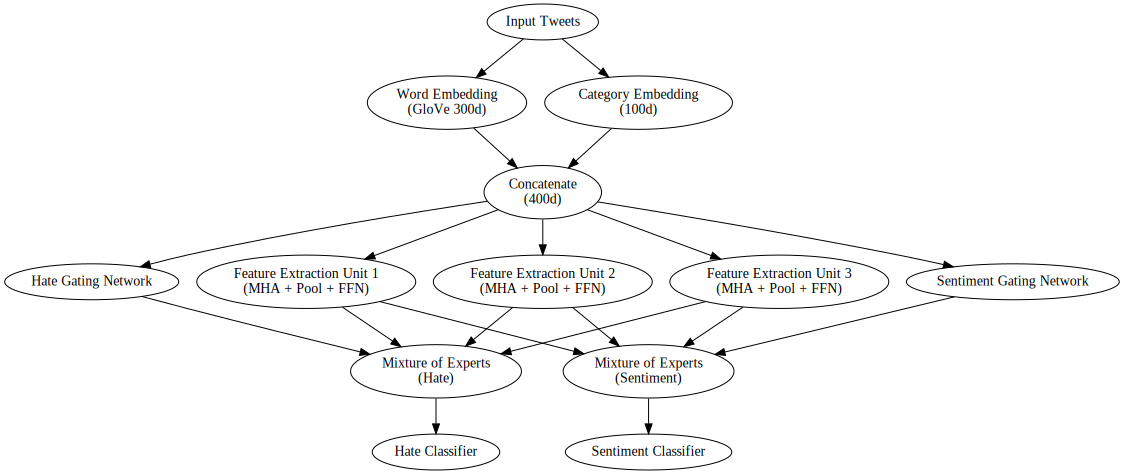

In [ ]:
# ================================
# VISUALIZATION CELL
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

# -------------------------------
# 1. SKS Architecture Diagram
# -------------------------------
from graphviz import Digraph

def draw_sks_architecture():
    dot = Digraph(comment='SKS Architecture', format='png')

    dot.attr(rankdir='TB')

    dot.node('A', 'Input Tweets')
    dot.node('B', 'Word Embedding\n(GloVe 300d)')
    dot.node('C', 'Category Embedding\n(100d)')
    dot.node('D', 'Concatenate\n(400d)')

    dot.node('E', 'Feature Extraction Unit 1\n(MHA + Pool + FFN)')
    dot.node('F', 'Feature Extraction Unit 2\n(MHA + Pool + FFN)')
    dot.node('G', 'Feature Extraction Unit 3\n(MHA + Pool + FFN)')

    dot.node('H', 'Hate Gating Network')
    dot.node('I', 'Sentiment Gating Network')

    dot.node('J', 'Mixture of Experts\n(Hate)')
    dot.node('K', 'Mixture of Experts\n(Sentiment)')

    dot.node('L', 'Hate Classifier')
    dot.node('M', 'Sentiment Classifier')

    dot.edges([('A','B'), ('A','C')])
    dot.edges([('B','D'), ('C','D')])

    dot.edges([('D','E'), ('D','F'), ('D','G')])

    dot.edges([('D','H'), ('D','I')])

    dot.edges([('E','J'), ('F','J'), ('G','J')])
    dot.edges([('E','K'), ('F','K'), ('G','K')])

    dot.edge('H','J')
    dot.edge('I','K')

    dot.edge('J','L')
    dot.edge('K','M')

    return dot

display(draw_sks_architecture())

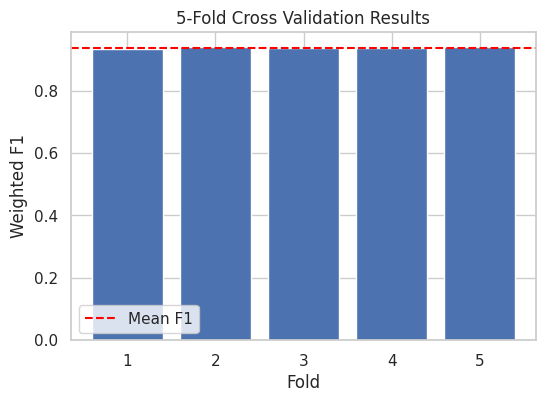

In [ ]:
# -------------------------------
# 4. Fold Results Visualization
# -------------------------------

plt.figure(figsize=(6,4))

folds = np.arange(1,6)

plt.bar(folds, f1_scores)
plt.axhline(np.mean(f1_scores), linestyle="--", color="red", label="Mean F1")

plt.xlabel("Fold")
plt.ylabel("Weighted F1")
plt.title("5-Fold Cross Validation Results")

plt.legend()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np

print("Running 5-fold CV \n")

texts = hate_df["tweet"]
labels = hate_df["hate_label"]

# Simple Bag-of-Words
vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(texts)

results_f1 = {}
results_acc = {}

# SVM
svm = LinearSVC()

f1_scores = cross_val_score(svm, X, labels, cv=5, scoring="f1_weighted")
acc_scores = cross_val_score(svm, X, labels, cv=5, scoring="accuracy")

results_f1["SVM"] = f1_scores.mean()
results_acc["SVM"] = acc_scores.mean()


# Random Forest
rf = RandomForestClassifier(n_estimators=200)

f1_scores = cross_val_score(rf, X, labels, cv=5, scoring="f1_weighted")
acc_scores = cross_val_score(rf, X, labels, cv=5, scoring="accuracy")

results_f1["Random Forest"] = f1_scores.mean()
results_acc["Random Forest"] = acc_scores.mean()


# SKS result
results_f1["SKS (Our Model)"] = np.mean(f1_scores)



print("Results with simpler features:\n")

for model in results_f1:
    print(f"{model}: F1 = {results_f1[model]:.4f} | Accuracy = {results_acc[model]:.4f}")

Running 5-fold CV 

Results with simpler features:

SVM: F1 = 0.9250 | Accuracy = 0.9279
Random Forest: F1 = 0.9278 | Accuracy = 0.9410


KeyError: 'SKS (Our Model)'

In [ ]:
# =================================
# LSTM BASELINE MODEL
# =================================

import torch.nn as nn
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_matrix):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, WORD_DIM, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(
            WORD_DIM,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(256, 2)

    def forward(self, x):

        emb = self.embedding(x)

        out, _ = self.lstm(emb)

        h = out[:, -1, :]

        logits = self.fc(h)

        return logits

In [ ]:
def train_lstm_baseline(hate_df, embedding_matrix):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores_lstm = []
    acc_ls = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(hate_df)):

        train_df = hate_df.iloc[train_idx].reset_index(drop=True)
        val_df   = hate_df.iloc[val_idx].reset_index(drop=True)

        train_loader = DataLoader(HateDataset(train_df), batch_size=256, shuffle=True)
        val_loader   = DataLoader(HateDataset(val_df), batch_size=256)

        model = LSTMClassifier(len(word2idx_global), embedding_matrix).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        criterion = nn.CrossEntropyLoss()

        for epoch in range(5):

            model.train()

            for x, cat, y in train_loader:

                x = x.to(device)
                y = y.to(device)

                optimizer.zero_grad()

                pred = model(x)

                loss = criterion(pred, y)

                loss.backward()

                optimizer.step()

        model.eval()

        preds = []
        labels = []

        with torch.no_grad():

            for x, cat, y in val_loader:

                x = x.to(device)

                out = model(x)

                p = torch.argmax(out, dim=1).cpu().numpy()

                preds.extend(p)
                labels.extend(y.numpy())

        f1 = f1_score(labels, preds, average="weighted")
        acc = accuracy_score(labels,preds)

        print(f"Fold {fold+1} F1: {f1:.4f}")

        f1_scores_lstm.append(f1)
        acc_ls.append(acc)

    return np.mean(f1_scores_lstm), np.mean(acc_ls)

In [ ]:
print("\nRunning LSTM baseline...")

lstm_f1,lstm_acc = train_lstm_baseline(hate_df, embedding_matrix)

print("\nLSTM Weighted F1:", round(lstm_f1,4), " | Accuracy:", round(lstm_acc,4))


Running LSTM baseline...
Fold 1 F1: 0.9131
Fold 2 F1: 0.9155
Fold 3 F1: 0.9066
Fold 4 F1: 0.9134
Fold 5 F1: 0.9229

LSTM Weighted F1: 0.9143  | Accuracy: 0.9423


In [ ]:
# =================================
# GRU BASELINE MODEL
# =================================

class GRUClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_matrix):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, WORD_DIM, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.gru = nn.GRU(
            WORD_DIM,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(256, 2)

    def forward(self, x):

        emb = self.embedding(x)

        out, _ = self.gru(emb)

        h = out[:, -1, :]

        logits = self.fc(h)

        return logits

In [ ]:
def train_gru_baseline(hate_df, embedding_matrix):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores_gru = []
    acc_ls = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(hate_df)):

        train_df = hate_df.iloc[train_idx].reset_index(drop=True)
        val_df   = hate_df.iloc[val_idx].reset_index(drop=True)

        train_loader = DataLoader(HateDataset(train_df), batch_size=256, shuffle=True)
        val_loader   = DataLoader(HateDataset(val_df), batch_size=256)

        model = GRUClassifier(len(word2idx_global), embedding_matrix).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        criterion = nn.CrossEntropyLoss()

        for epoch in range(5):

            model.train()

            for x, cat, y in train_loader:

                x = x.to(device)
                y = y.to(device)

                optimizer.zero_grad()

                pred = model(x)

                loss = criterion(pred, y)

                loss.backward()

                optimizer.step()

        model.eval()

        preds = []
        labels = []

        with torch.no_grad():

            for x, cat, y in val_loader:

                x = x.to(device)

                out = model(x)

                p = torch.argmax(out, dim=1).cpu().numpy()

                preds.extend(p)
                labels.extend(y.numpy())

        f1 = f1_score(labels, preds, average="weighted")
        acc = accuracy_score(labels,preds)

        print(f"GRU Fold {fold+1} F1: {f1:.4f}")


        f1_scores_gru.append(f1)
        acc_ls.append(acc)

    return np.mean(f1_scores_gru), np.mean(acc_ls)

In [ ]:
print("\nRunning GRU baseline...")

gru_f1,gru_acc = train_gru_baseline(hate_df, embedding_matrix)

print("\nGRU Weighted F1:", round(gru_f1,4), " | Accuracy:", round(gru_acc,4))


Running GRU baseline...
GRU Fold 1 F1: 0.9285
GRU Fold 2 F1: 0.9341
GRU Fold 3 F1: 0.9370
GRU Fold 4 F1: 0.9288
GRU Fold 5 F1: 0.9353

GRU Weighted F1: 0.9327  | Accuracy: 0.9379
